y at x≈15 for each h:
h= 0.01 y= 0.23072198238911457 exact= 0.2723749469966798
h= 0.05 y= 0.12131231300557774 exact= 0.2723749469966798
h= 0.15 y= 0.02196322279546107 exact= 0.2723749469966798
h= 0.2 y= 0.007995379767749037 exact= 0.2723749469966798
h= 0.25 y= 0.002506408181234753 exact= 0.2723749469966798
h= 0.3 y= 0.0007087097542026885 exact= 0.2723749469966798
h= 0.35 y= 0.00015963086370969243 exact= 0.2723749469966798
h= 0.4 y= 2.241437709878674e-05 exact= 0.2723749469966798
h= 0.45 y= 7.401922952713638e-07 exact= 0.2723749469966798
h= 0.5 y= 0.0 exact= 0.2723749469966798
h= 0.55 y= 2.2061751823372104e-09 exact= 0.2723749469966798
h= 0.6 y= -2.3905167932158e-07 exact= 0.2723749469966798
h= 0.65 y= 9.207443669626847e-06 exact= 0.2723749469966798
h= 0.7 y= 7.626695583212951e-06 exact= 0.2723749469966798
h= 0.75 y= 0.0009395421459486341 exact= 0.2723749469966798
h= 0.8 y= 0.007937868451135574 exact= 0.2723749469966798
h= 0.85 y= 0.032118010577248904 exact= 0.2723749469966798
h= 0.9 y=

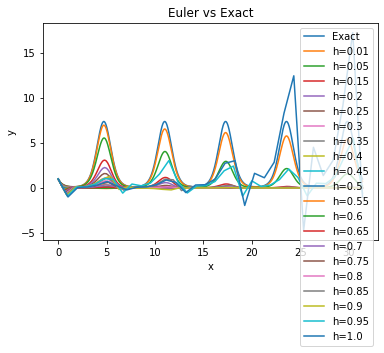

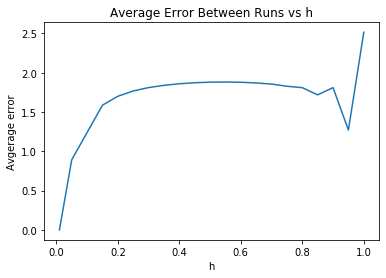

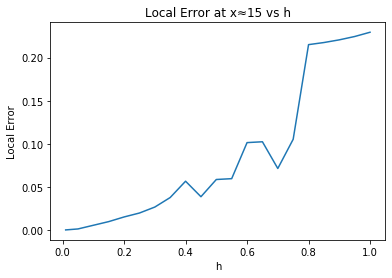

In [2]:
import numpy as np
import matplotlib.pyplot as plt

x_start = 0
x_end = 10 * np.pi
y0 = 1

def f(x, y):
    return -2 * y * np.cos(x)

def exact(x):
    return np.exp(-2 * np.sin(x))

def euler(h):
    n = int(round((x_end - x_start) / h))
    x = np.linspace(x_start, x_end, n + 1)
    y = np.zeros(n + 1)
    y[0] = y0
    for i in range(n):
        y[i+1] = y[i] + h * f(x[i], y[i])
    return x, y

def local_error(h):
    n = int(round((x_end - x_start) / h))
    x = np.linspace(x_start, x_end, n + 1)
    error = np.zeros(n + 1)
    for i in range(n):
        y_ex = exact(x[i])
        error[i+1] = abs(exact(x[i+1]) - (y_ex + h * f(x[i], y_ex)))
    return x, error

step_sizes = [0.01, 0.05] + list(np.arange(0.15, 1.01, 0.05).round(10))

avg_y_values = []
y_at_15 = []
for h in step_sizes:
    x, y = euler(h)
    avg_y_values.append(np.mean(y))
    idx = np.argmin(np.abs(x - 15))
    y_at_15.append(y[idx])

print("y at x≈15 for each h:")
for h, val in zip(step_sizes, y_at_15):
    print("h=", h, "y=", val, "exact=", exact(15))

# Plot 1
x_fine = np.linspace(x_start, x_end, 5000)
plt.figure()
plt.plot(x_fine, exact(x_fine), label='Exact')
for h in step_sizes:
    x, y = euler(h)
    plt.plot(x, y, label=f"h={h}")
plt.title("Euler vs Exact")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

# Plot 2
x_ref, y_ref = euler(step_sizes[0])
avg_errors_between_runs = []
for h in step_sizes:
    x, y = euler(h)
    y_ref_interp = np.interp(x, x_ref, y_ref)
    avg_errors_between_runs.append(np.mean(np.abs(y - y_ref_interp)))

plt.figure()
plt.plot(step_sizes, avg_errors_between_runs)
plt.title("Average Error Between Runs vs h")
plt.xlabel("h")
plt.ylabel("Avgerage error")
plt.show()

# Plot 3
local15 = []
for h in step_sizes:
    x, err = local_error(h)
    idx = np.argmin(np.abs(x - 15))
    local15.append(err[idx])

plt.figure()
plt.plot(step_sizes, local15)
plt.title("Local Error at x≈15 vs h")
plt.xlabel("h")
plt.ylabel("Local Error")
plt.show()


# For plot 1: As h gets bigger, euler falls apart. As h gets bigger it collapses to 0 because 
# big steps cant stick with cosx changing signs. 
# For plot 2 and 3: Error grows with h and some step sizes happen to land on points where the error is 
# smaller just by coincidence, which is why the plots arent a perfectly smooth curve.

#Addendum 
# For f = -2y we found lamda=-2 and the stability condition was h<=1. Taking the derivative with respect 
# to y = -2cos(x). The difference is lamda is not a number anymore, it depends on x. Lamda = -2cos(x), and 
# the worst case is when cosx = 1, which gives λ = -2. So we plug in λ = -2 and get h<=1. 